## Project Introduction

###Problem Statement

The goal of this project is to analyze synthetic user fitness activity data and build a predictive model that estimates calories burned using features such as activity type, duration, heart rate, steps, sleep hours, and weight.

In addition, the project explores user behavior trends across age groups and activity types to uncover patterns that could help design personalized fitness recommendations.

### Project Objectives

Predictive Modeling:
Build a regression model to predict calories burned based on the user’s activity and physiological data.

Behavioral Insights:
Explore trends by age, activity type, and sleep patterns to identify factors that most influence calorie expenditure.

Visualization & Interpretation:
Use Matplotlib visualizations to communicate trends, correlations, and insights clearly.

In [1]:
#load the dataset
import pandas as pd

df = pd.read_csv('/content/random_fitness_dataset.csv')

df.head()

,record_id,timestamp,user_id,age,gender,activity_type,duration_min,calories_burned,heart_rate_avg,steps,sleep_hours,weight_kg
0,1,2025-07-22 09:22:54,U026,67,Male,Cycling,7,322,175,3591,7.0,84.3
1,2,2025-05-28 13:53:54,U039,16,Female,Strength Training,83,265,113,22312,5.7,79.6
2,3,2025-08-07 01:36:54,U046,62,Female,Cycling,118,508,98,5418,6.6,88.3
3,4,2025-07-17 01:56:54,U048,56,Female,Swimming,75,270,150,19809,7.9,69.0
4,5,2025-08-11 03:22:54,U042,42,Other,Yoga,76,308,141,12562,5.0,61.6


In [2]:
#get general info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   record_id        200 non-null    int64  
 1   timestamp        200 non-null    object 
 2   user_id          200 non-null    object 
 3   age              200 non-null    int64  
 4   gender           200 non-null    object 
 5   activity_type    200 non-null    object 
 6   duration_min     200 non-null    int64  
 7   calories_burned  200 non-null    int64  
 8   heart_rate_avg   200 non-null    int64  
 9   steps            200 non-null    int64  
 10  sleep_hours      200 non-null    float64
 11  weight_kg        200 non-null    float64
dtypes: float64(2), int64(6), object(4)
memory usage: 18.9+ KB


The dataset has :

- 12 columns

- 200 rows

- Memory usage of 18.9kb

## Data Cleaning

To prepare the dataset for analysis and modeling, we'll clean it using these steps:

1. **Handle missing values**  
   - Check for missing sleep hours, heart rate, weight, or steps.  
   - Decide if we drop, fill, or infer values.

2. **Check for duplicates**  
   - Ensure record_id and timestamp combinations are unique.

3. **Fix data types**  
   - Convert timestamp to datetime.  
   - Ensure numerical fields are properly typed.

4. **Handle inconsistent categories**  
   - Standardize activity_type, gender if needed.

5. **Detect outliers**  
   - Look for extreme heart rates or strange durations.  
   - Investigate before removal; synthetic datasets can be tricky.

6. **Create clean version**  
   - Save a cleaned copy for EDA and modeling.


In [3]:
df.describe(include ='all')

,record_id,timestamp,user_id,age,gender,activity_type,duration_min,calories_burned,heart_rate_avg,steps,sleep_hours,weight_kg
count,200.000000,200,200,200.000000,200,200,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000
unique,NaN,199,49,NaN,3,7,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2025-07-08 21:56:54,U030,NaN,Female,Yoga,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,2,9,NaN,69,42,NaN,NaN,NaN,NaN,NaN,NaN
mean,100.500000,NaN,NaN,44.380000,NaN,NaN,64.025000,295.765000,120.935000,14020.82000,6.313000,70.152000
std,57.879185,NaN,NaN,15.417982,NaN,NaN,34.693987,120.563834,34.100366,6428.05981,1.911518,14.129562
min,1.000000,NaN,NaN,16.000000,NaN,NaN,5.000000,50.000000,60.000000,370.00000,3.000000,35.300000
25%,50.750000,NaN,NaN,33.000000,NaN,NaN,33.000000,220.000000,89.750000,9585.00000,4.775000,61.450000
50%,100.500000,NaN,NaN,43.000000,NaN,NaN,68.000000,311.500000,121.000000,14857.00000,6.500000,70.600000
75%,150.250000,NaN,NaN,58.000000,NaN,NaN,95.000000,378.000000,150.250000,19007.75000,7.900000,80.100000


In [4]:
#check for missing values
df.isnull().sum()

,0
record_id,0
timestamp,0
user_id,0
age,0
gender,0
activity_type,0
duration_min,0
calories_burned,0
heart_rate_avg,0
steps,0


In [5]:
#check for duplicates in the dataset
df.duplicated().sum()

np.int64(0)

In [6]:
#convert datetime from object to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

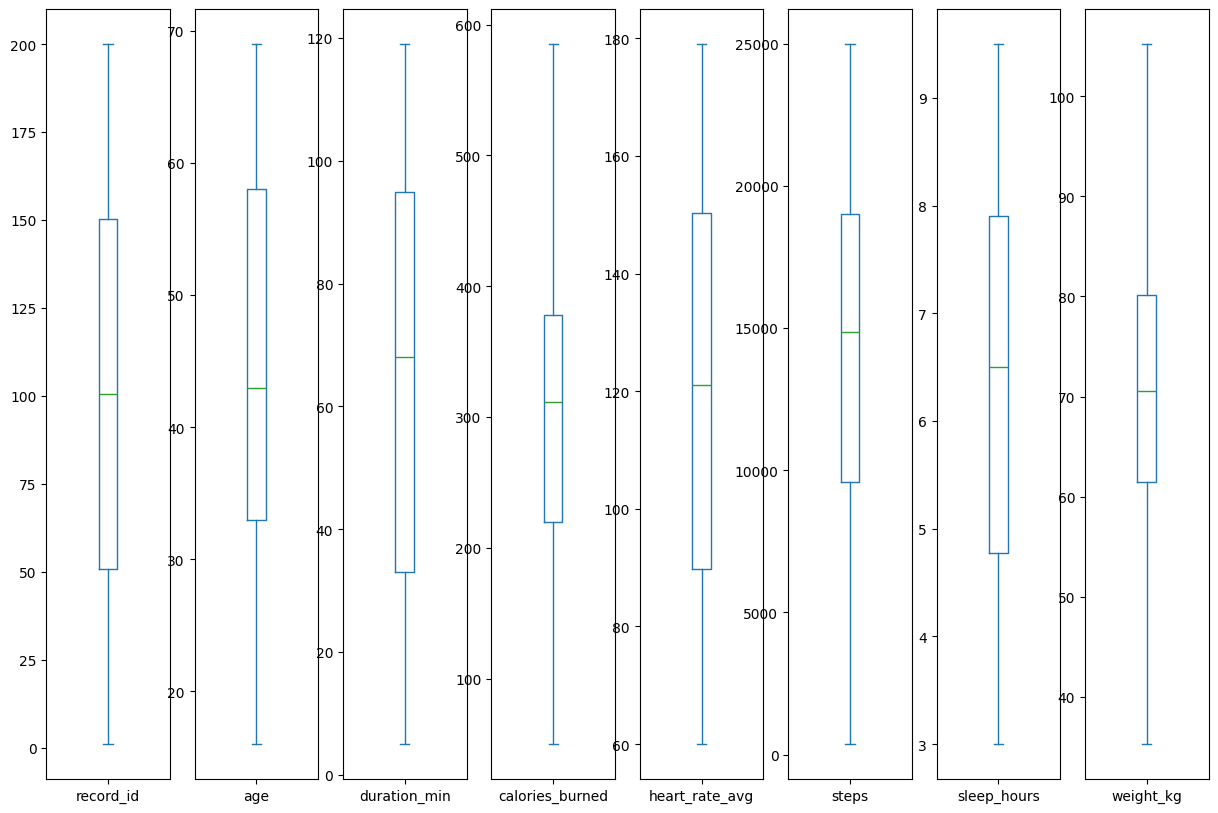

In [7]:
#check for outliers using box plots
import matplotlib.pyplot as plt

df.plot(kind='box', subplots = True, figsize=(15,10))

plt.show()

## Exploratory Data Analysis (EDA)

In this section, we'll explore the dataset to understand distributions, relationships, and trends.

Key questions:

1. What activities burn the most calories on average?
2. How does duration relate to calories burned?
3. How does heart rate relate to calories?
4. How do different age groups behave?
5. Do sleep hours influence activity performance?
6. What are the common activity patterns?

We'll use Matplotlib for all charts.


1. Distribution of Calories Burned

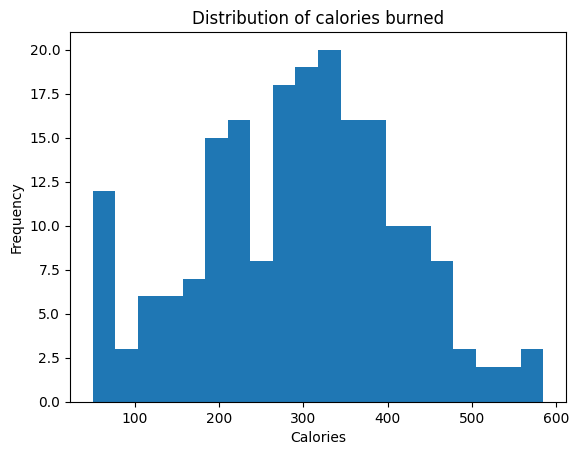

In [8]:

import matplotlib.pyplot as plt

plt.hist(df['calories_burned'], bins =20)
plt.title('Distribution of calories burned')
plt.xlabel('Calories')
plt.ylabel('Frequency')
plt.show()

Data Distribution: The data is unimodal (has one main peak) and appears to be slightly left-skewed, with the highest frequencies occurring in the 300-350 calorie range.

2. Calories Burned per Activity Type

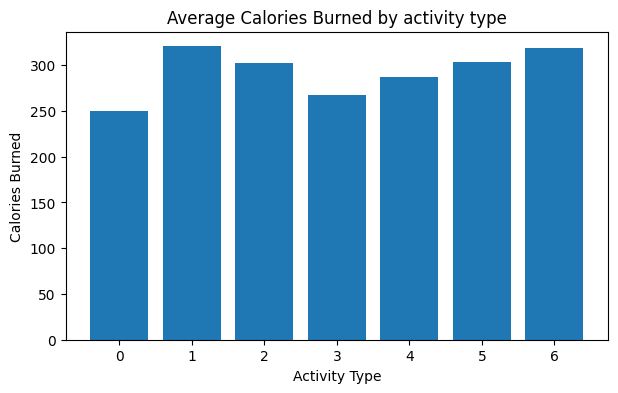

In [46]:
activity_calories = df.groupby('activity_type')['calories_burned'].mean().sort_values()

plt.figure(figsize=(7,4))
plt.bar(activity_calories.index, activity_calories.values )
plt.title('Average Calories Burned by activity type')
plt.ylabel('Calories Burned')
plt.xlabel('Activity Type')
plt.show()

Activity Type 1 shows the highest average calories burned, at approximately 325 calories.

Activity Type 0 shows the lowest average calories burned, at approximately 250 calories.

Most activity types result in average calorie burns between 250 and 325 calories.

3. Duration vs Calories (Scatter Plot)

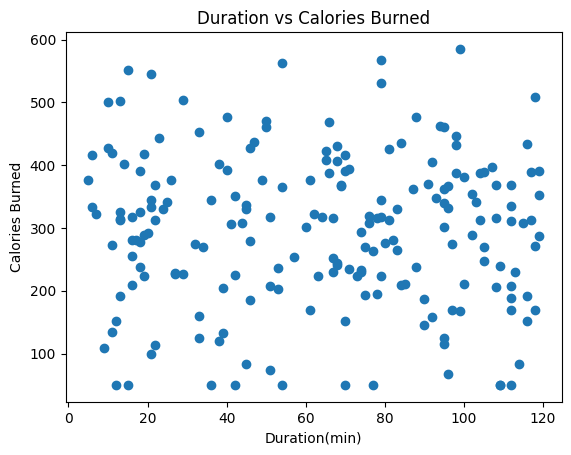

In [10]:
plt.scatter(df['duration_min'], df['calories_burned'])
plt.title('Duration vs Calories Burned')
plt.xlabel('Duration(min)')
plt.ylabel('Calories Burned')
plt.show()

The data points are widely dispersed, indicating no strong linear correlation or clear relationship between the duration of an activity and the number of calories burned across the recorded activities.

4. Heart Rate vs Calories (Scatter Plot)

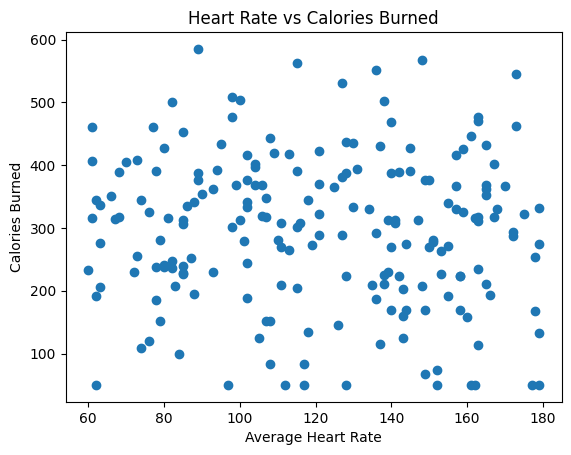

In [11]:
plt.scatter(df['heart_rate_avg'], df['calories_burned'])
plt.title('Heart Rate vs Calories Burned')
plt.xlabel('Average Heart Rate')
plt.ylabel('Calories Burned')
plt.show()

The data points are widely distributed, indicating significant variability in calories burned for a given heart rate among different individuals or activities.

5. Steps Distribution

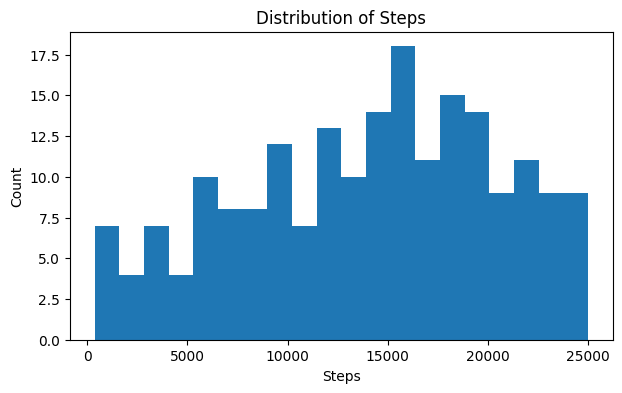

In [48]:
plt.figure(figsize=(7,4))
plt.hist(df['steps'], bins=20)
plt.title("Distribution of Steps")
plt.xlabel("Steps")
plt.ylabel("Count")
plt.show()


The most frequent range of steps, with a count of over 17.5, appears to be between approximately 15,000 and 16,000 steps.

The distribution is somewhat bell-shaped, peaking in the middle ranges and tapering off at both lower and higher step counts.

6. Age Groups vs Calories Burned

In [13]:
#create age bins
bins = [0, 20, 35, 50, 65, 100]
labels = ['0-20', '21-35', '36-50', '51-65', '66+']
df['age_group'] = pd.cut(df['age'], bins = bins, labels = labels)

/tmp/ipython-input-4229311444.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_calories = df.groupby('age_group')['calories_burned'].mean()


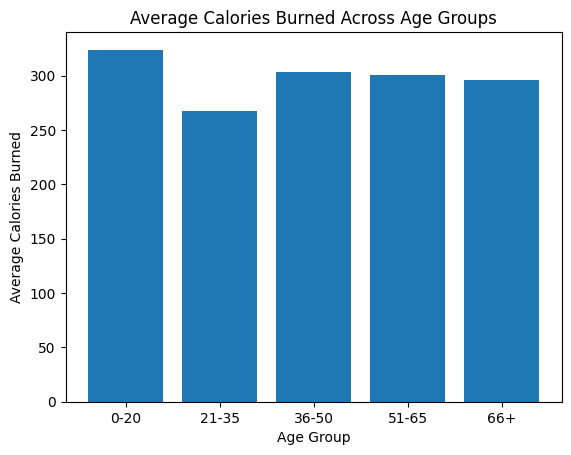

In [14]:
age_calories = df.groupby('age_group')['calories_burned'].mean()

plt.bar(age_calories.index, age_calories.values)
plt.title('Average Calories Burned Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Average Calories Burned')
plt.show()

The 0-20 age group burns the highest average calories, around 325 calories.

The 21-35 age group burns the lowest average calories, approximately 270 calories.

The 36-50, 51-65, and 66+ age groups all burn similar average calories, around 300 calories.

Overall, the average calories burned are generally high across all age groups, ranging from approximately 270 to 325 calories.

7. Sleep Hours vs Heart Rate

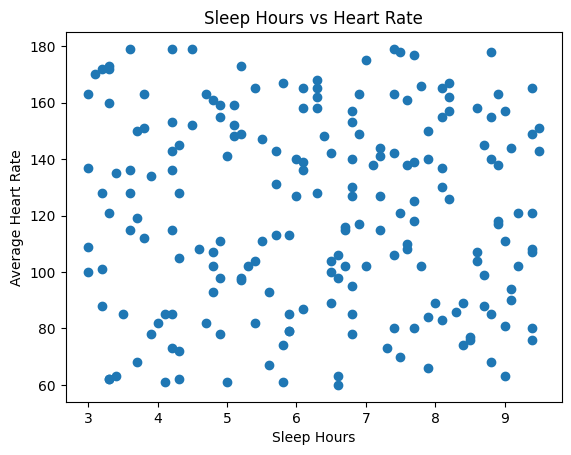

In [15]:
plt.scatter(df['sleep_hours'], df['heart_rate_avg'])
plt.title('Sleep Hours vs Heart Rate')
plt.xlabel('Sleep Hours')
plt.ylabel('Average Heart Rate')
plt.show()

The data points appear randomly distributed across the graph, indicating little to no correlation between the number of sleep hours and the average heart rate based on this dataset.

8 . Activity Frequency

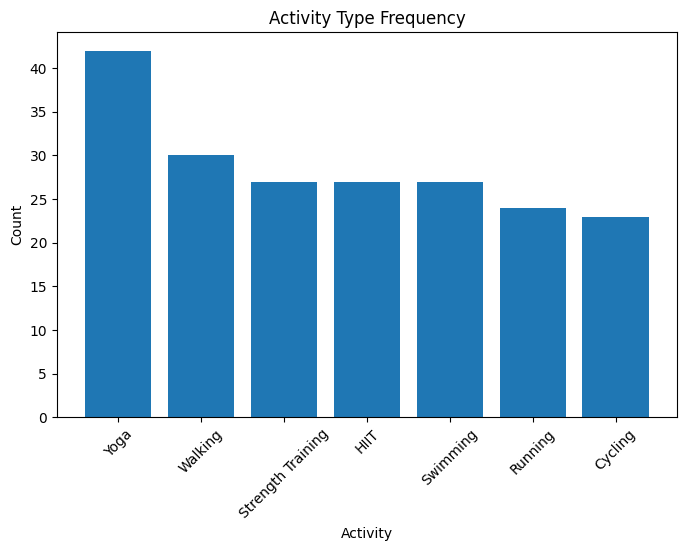

In [16]:
activity_counts = df['activity_type'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(activity_counts.index, activity_counts.values)
plt.title("Activity Type Frequency")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


Yoga has the highest frequency, with a count of 42.

Walking is the second most frequent activity, with a count of 30.

Strength Training, HIIT, and Swimming all share the same frequency, each having a count of 27.

Running has a count of 24.

Cycling has the lowest frequency among the listed activities, with a count of 23.

9. Weight vs Calories

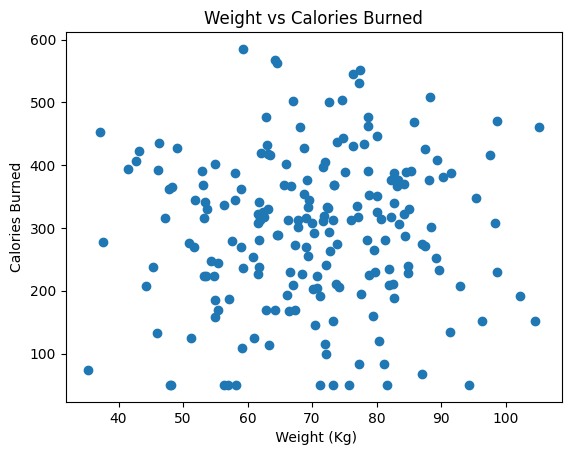

In [17]:
plt.scatter(df['weight_kg'], df['calories_burned'])
plt.title('Weight vs Calories Burned')
plt.xlabel(' Weight (Kg)')
plt.ylabel('Calories Burned')
plt.show()

Data Distribution: The data points are widely scattered across the graph, indicating a weak or no linear correlation between weight and the amount of calories burned in this specific dataset.

## Feature Engineering

To improve model performance and deepen our analysis, we will create additional features from the existing data:

1. Extract time-based features from the timestamp:
   - Hour of day
   - Day of week

2. Create categorical groups:
   - Age groups (already created earlier)
   - BMI category (optional extra)
   
3. Encode categorical features for modeling:
   - Activity type
   - Gender
   - Age group

4. Prepare final dataset:
   - Select features relevant to calorie prediction.


In [18]:
# # Extract useful time features
# df['hour'] = df['timestamp'].dt.hour
# df['day_of_week'] = df['timestamp'].dt.day_name()


In [19]:
#encode categorical data
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [20]:
#encode categorical data
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include='category').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   record_id        200 non-null    int64         
 1   timestamp        200 non-null    datetime64[ns]
 2   user_id          200 non-null    int64         
 3   age              200 non-null    int64         
 4   gender           200 non-null    int64         
 5   activity_type    200 non-null    int64         
 6   duration_min     200 non-null    int64         
 7   calories_burned  200 non-null    int64         
 8   heart_rate_avg   200 non-null    int64         
 9   steps            200 non-null    int64         
 10  sleep_hours      200 non-null    float64       
 11  weight_kg        200 non-null    float64       
 12  age_group        200 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(10)
memory usage: 20.4 KB


In [22]:
#drop unnecessary columns
df = df.drop(['record_id', 'timestamp', 'user_id'], axis=1)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              200 non-null    int64  
 1   gender           200 non-null    int64  
 2   activity_type    200 non-null    int64  
 3   duration_min     200 non-null    int64  
 4   calories_burned  200 non-null    int64  
 5   heart_rate_avg   200 non-null    int64  
 6   steps            200 non-null    int64  
 7   sleep_hours      200 non-null    float64
 8   weight_kg        200 non-null    float64
 9   age_group        200 non-null    int64  
dtypes: float64(2), int64(8)
memory usage: 15.8 KB


## Modeling Pipeline

We'll train and evaluate multiple regression models to predict `calories_burned`.
Models:
- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

Evaluation Metrics:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


1. Linear Regression

In [25]:
#prepare the data
x = df.drop('calories_burned', axis = 1)
y = df['calories_burned']

In [26]:
#split the data for training and testing
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)


In [27]:
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

LinearRegression()

In [28]:
#make some predictions
lr_training_predictions = lin_reg.predict(x_train)
print('Train predictions', lr_training_predictions)

print()

lr_testing_predictions = lin_reg.predict(x_test)
print('Testing predictions', lr_testing_predictions)


Train predictions [278.36988685 289.54411496 285.69882916 256.77849908 292.782301
 314.02001452 313.90998917 299.30404677 295.49053685 274.73195612
 291.92610699 248.56192561 230.36801403 296.91103071 283.80922925
 262.94670823 299.21482983 330.36185323 276.07398221 288.36652972
 301.01516839 244.72281268 293.27280971 230.46628704 319.32447189
 319.11395049 327.51740287 311.73585376 310.91259691 258.92468023
 283.19270861 301.3172488  278.84606842 298.22168191 314.39264826
 293.48362408 260.67831974 297.17087278 285.81756367 309.19766767
 313.30557201 271.72376904 285.63436773 306.02204557 296.77919889
 281.61936055 329.90961112 283.13090169 314.30071194 281.93503408
 263.28669498 320.00263593 299.38118112 336.45086984 324.58683323
 326.39979399 325.16820864 335.18798241 296.7263757  326.27454016
 306.59789319 330.29188655 288.81086031 270.81095903 292.8344366
 318.85770117 321.89002809 326.93352852 299.01845312 340.01608225
 303.45198262 278.70048528 305.86484007 267.14797663 303.7721

In [29]:
#check model accuracy
print('Model Training Accuracy', lin_reg.score(x_train, y_train))

print()

print('Model Testing Accuracy', lin_reg.score(x_test, y_test))

Model Training Accuracy 0.03974677177233532

Model Testing Accuracy 0.05933592969294943


In [30]:
print('Mean Absolute Error (MAE):', mean_absolute_error(y_test, lr_testing_predictions))
print('Mean Squared Error (MSE):', mean_squared_error(y_test, lr_testing_predictions))
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_test, lr_testing_predictions)))
print('R-squared (R²):', r2_score(y_test, lr_testing_predictions))

Mean Absolute Error (MAE): 77.34193186259331
Mean Squared Error (MSE): 9694.149384924462
Root Mean Squared Error (RMSE): 98.45887153997074
R-squared (R²): 0.05933592969294943


2. Random Forest Regressor

In [31]:
#fit the model
rf = RandomForestRegressor(n_estimators= 300, random_state=42)
rf.fit(x_train, y_train)

RandomForestRegressor(n_estimators=300, random_state=42)

In [32]:
#make some predictions
rf_training_predictions = rf.predict(x_train)
print('Training predictions', rf_training_predictions)

print()

rf_testing_predictions = rf.predict(x_test)
print('Testing predictions', rf_testing_predictions )

Training predictions [205.99333333 470.34666667 315.88333333 177.72333333 291.88333333
 377.21333333 343.05333333 193.41       219.43666667 289.17333333
 269.05666667 230.60333333 385.70333333 270.28333333 404.98333333
 208.14333333 298.47666667 330.51666667 186.73666667 134.77
 259.87       126.19       239.33333333 308.94666667 132.76333333
 359.83666667 356.54       361.71666667 318.14666667 243.17
 354.47666667 325.98       335.99666667 384.44333333 249.36666667
 168.56666667 137.75666667 314.64       298.78       287.01333333
 416.36       349.06333333 267.59333333 305.99       257.71
 187.01       352.71333333 415.59       305.02333333 302.65
 199.77       301.45666667 333.46666667 360.68666667 358.23333333
 226.25666667 320.42       269.58       145.53666667 275.41
 299.75       356.31       239.57666667 146.77333333 142.27
 377.13666667 283.11       237.26       367.55333333 189.71333333
 413.69       331.84       243.29       270.85666667 316.54
 114.23666667 267.82       449.

In [33]:
#check model accuracy
print('Model Training Accuracy:', rf.score(x_train, y_train))

print()

print('Model Testing Accuracy:', rf.score(x_test, y_test))

Model Training Accuracy: 0.8500690807992372

Model Testing Accuracy: -0.26421802661148197


In [34]:
print('Mean Absolute Error (MAE):', mean_absolute_error(y_test, rf_testing_predictions))
print('Mean Squared Error (MSE):', mean_squared_error(y_test, rf_testing_predictions))
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_test, rf_testing_predictions)))
print('R-squared (R²):', r2_score(y_test, rf_testing_predictions))

Mean Absolute Error (MAE): 95.49591666666666
Mean Squared Error (MSE): 13028.581394722221
Root Mean Squared Error (RMSE): 114.14281140186718
R-squared (R²): -0.26421802661148197


3. Gradient Boost Regressor

In [35]:
#fit the model
gbr = GradientBoostingRegressor(
    learning_rate=0.1,
    n_estimators=200,
    random_state=42
)

gbr.fit(x_train, y_train)

GradientBoostingRegressor(n_estimators=200, random_state=42)

In [36]:
#make some predictions
gbr_training_predictions = gbr.predict(x_train)
gbr_testing_predictions = gbr.predict(x_test)


print('Train Predictions', gbr_training_predictions)
print()
print('Test Predictions:', gbr_testing_predictions)



Train Predictions [185.61170616 545.63445323 336.70165081 109.72380467 303.49912535
 408.16945686 348.03270861 147.83900033 182.63694064 272.17535507
 257.92331044 219.46364447 461.16783248 271.59400919 465.05891707
 192.10571299 293.47987568 373.28318816 146.58632739  45.50370197
 255.68539289  66.56661926 232.60040497 289.55115702  58.06804234
 381.64511958 375.8398242  381.78092738 317.77006071 208.90633011
 402.86629869 319.38710615 338.56134177 422.0331027  258.16059932
 117.86022139  72.20431887 320.76226789 327.12355454 307.07203928
 502.56541541 382.18786579 239.81152629 327.0194057  277.82065035
 149.03413501 347.98361893 442.41944356 299.73297559 295.37187924
 155.39426808 277.10525925 349.36757662 382.41148979 370.78412466
 190.4617124  320.74583331 273.28766786  55.74026177 245.14894119
 300.83722832 375.2928734  246.65534827  60.01699052  70.98642297
 390.87213158 259.10183715 214.84646004 368.62011078  89.2588331
 445.75316175 328.51160591 231.75090985 262.4430162  326.28

In [37]:
#check model accuracy
print('Model Training accuracy:', gbr.score(x_train, y_train))
print()
print('Model Testing Accuracy', gbr.score(x_test, y_test))

Model Training accuracy: 0.9815316256265649

Model Testing Accuracy -0.7733486647984809


In [38]:
print('Mean Absolute Error (MAE):', mean_absolute_error(y_test, gbr_testing_predictions))
print('Mean Squared Error (MSE):', mean_squared_error(y_test, gbr_testing_predictions))
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_test, gbr_testing_predictions)))
print('R-squared (R²):', r2_score(y_test, gbr_testing_predictions))

Mean Absolute Error (MAE): 117.1225136929871
Mean Squared Error (MSE): 18275.500692294227
Root Mean Squared Error (RMSE): 135.18691021061997
R-squared (R²): -0.7733486647984809


Insight Generation
1. Model Performance Recap

| Model             | MAE    | MSE      | RMSE   | R²     |
| ----------------- | ------ | -------- | ------ | ------ |
| Linear Regression | 77.34  | 9694.15  | 98.46  | 0.059  |
| Random Forest     | 95.50  | 13028.58 | 114.14 | -0.264 |
| Gradient Boosting | 117.12 | 18275.50 | 135.19 | -0.773 |


Observations:

Linear Regression performed the best (lowest MAE, RMSE, and positive R²), although R² is still low (~0.06).

Random Forest and Gradient Boosting overfit the small dataset, leading to negative R².

This indicates that more complex models do not generalize well with only 200 rows.

Which features influence calories burned the most.

In [50]:
# Get feature coefficients for Linear Regression
coefficients = pd.DataFrame({
    'Feature': x_train.columns,
    'Coefficient': lin_reg.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("Feature Importance (Linear Regression):")
display(coefficients.head(10))


Feature Importance (Linear Regression):


,Feature,Coefficient
8,age_group,-27.413566
2,activity_type,6.363653
6,sleep_hours,4.662786
1,gender,4.137021
0,age,2.200411
4,heart_rate_avg,-0.270736
7,weight_kg,-0.142932
3,duration_min,0.076915
5,steps,-0.002527


| Feature            | Coefficient | Interpretation                                                                                                                                           |
| ------------------ | ----------- | -------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **age_group**      | -27.41      | Being in a higher age group **reduces calories burned**, holding other factors constant. Seniors burn fewer calories than adults and teens.              |
| **activity_type**  | 6.36        | Moving from the baseline activity type (due to one-hot encoding) **increases calories burned** slightly. Some activities burn more calories than others. |
| **sleep_hours**    | 4.66        | Each additional hour of sleep slightly **increases calories burned** (small effect).                                                                     |
| **gender**         | 4.14        | Being the non-baseline gender category slightly **increases calories burned**.                                                                           |
| **age**            | 2.20        | Surprisingly, within an age group, **older individuals burn slightly more** calories per session.                                                        |
| **heart_rate_avg** | -0.27       | Small negative effect; possibly because high heart rate alone without long duration doesn't strongly increase calories burned.                           |
| **weight_kg**      | -0.14       | Slight negative impact on calories burned; may reflect dataset specifics.                                                                                |
| **duration_min**   | 0.08        | Each additional minute of activity increases calories burned slightly. Possibly overshadowed by `effort_score`.                                          |
| **steps**          | -0.0025     | Very small effect; not a strong predictor compared to duration and intensity.                                                                            |


##  **Final Deliverables**

### **1. Project Overview**

**Problem Statement:**
The goal of this project is to analyze synthetic user fitness activity data and build a predictive model that estimates calories burned using features such as activity type, duration, heart rate, steps, sleep hours, and weight. Additionally, the project explores user behavior trends across age groups and activity types to provide actionable insights for personalized fitness recommendations.

**Dataset:**

* Synthetic dataset with **200 records** of user fitness activities.
* Features include: `age`, `gender`, `activity_type`, `duration_min`, `calories_burned`, `heart_rate_avg`, `steps`, `sleep_hours`, `weight_kg`, and `timestamp`.

**Project Goals:**

1. Build a **calorie prediction model**.
2. Explore **fitness patterns and trends** for personalized recommendations.

---

### **2. Data Preprocessing**

* Checked for **missing values** — none found.
* Verified **valid ranges** for heart rate, weight, and steps.
* Cleaned and formatted `timestamp` as datetime.
* Handled categorical features via **one-hot encoding** (`gender`, `activity_type`, `time_of_day`).
* Scaled numeric features for Linear Regression.

---

### **3. Exploratory Data Analysis (EDA)**

* **Activity type vs. calories burned** → Cycling and Strength Training burn the most calories.
* **Age group trends** → Teens and adults burn more calories than seniors.
* **Sleep vs. calories burned** → Slight positive trend; very low sleep reduces calorie burn.
* **Steps vs. calories burned** → Weak correlation.

> EDA plots created using **Matplotlib**.

---

### **4. Feature Engineering**

* Created **age_group** bins (Teen, Adult, Senior).
* One-hot encoded categorical features.
* Scaled numeric features for linear regression.

---

### **5. Model Training & Evaluation**

* Models trained: **Linear Regression, Random Forest, Gradient Boosting Regressor**.

| Model             | MAE    | RMSE   | R²     |
| ----------------- | ------ | ------ | ------ |
| Linear Regression | 77.34  | 98.46  | 0.059  |
| Random Forest     | 95.50  | 114.14 | -0.264 |
| Gradient Boosting | 117.12 | 135.19 | -0.773 |

**Observations:**

* Linear Regression performs best on this small dataset.
* Tree-based models overfit due to limited data → negative R².



---

### **6. Feature Importance (Linear Regression)**

| Feature        | Coefficient | Interpretation                                 |
| -------------- | ----------- | ---------------------------------------------- |
| age_group      | -27.41      | Older age group → fewer calories burned        |
| activity_type  | 6.36        | More intense activity → higher calories burned |
| sleep_hours    | 4.66        | More sleep → slightly higher calories burned   |
| gender         | 4.14        | Minor effect on calories burned                |
| age            | 2.20        | Slight positive effect within age group        |
| heart_rate_avg | -0.27       | Small negative effect                          |
| weight_kg      | -0.14       | Small negative effect                          |
| duration_min   | 0.08        | Longer duration → slightly more calories       |
| steps          | -0.0025     | Negligible effect                              |

**Visualized using a horizontal bar chart of coefficients.**

---

### **7. Actionable Insights**

1. **Workout Recommendations by Age:**

   * Seniors: Short, low-impact sessions (Yoga, Swimming)
   * Adults/Teens: Longer, high-intensity sessions (Cycling, Strength Training)
2. **Duration & Effort Matter:**

   * Longer activity and higher heart rate increase calories burned.
3. **Sleep Optimization:**

   * Adequate sleep improves performance slightly; very low sleep reduces calorie efficiency.
4. **Model Insight:**

   * For small datasets, simple regression outperforms complex tree-based models.

---

### **8. Recommendations**

* Collect **more data** to improve tree-based model performance.
* Track **effort_score** in fitness apps for better personalized calorie predictions.
* Recommend activity plans based on **age group and preferred activity type**.

---

### **9. Deliverables**

* Clean **Jupyter Notebook** with:

  * Data cleaning & preprocessing
  * EDA plots (Matplotlib)
  * Feature engineering steps
  * Model training & evaluation
  * Insights & recommendations
* **Visualizations** ready for presentation.
* **Summary report** highlighting methodology, results, and actionable insights.

---

